<a href="https://colab.research.google.com/github/isocan/Pt111-MACE/blob/main/Pt111_H_coverage_differential_UMA_demo_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pt(111) H* coverage screening with UMA: 4×4 slab, ΔE and ΔG

This notebook is a demonstration of an **AdsorbML-style configuration funnel** for H* on Pt(111). It combines the useful parts of the earlier tutorial and Kaggle workflow, but corrects the surface size, coverage counting, differential-energy cycle, and gas-phase thermochemistry.

The workflow:

1. optimizes bulk Pt with UMA's **PBE-level `omat` task** and uses that lattice constant;
2. builds a four-layer **4×4 Pt(111)** slab (16 Pt atoms per layer, 64 Pt atoms total);
3. screens single-H placements first with high-symmetry/heuristic and random AdsorbML-style sampling;
4. screens 4H (0.25 ML) and 8H (0.50 ML) configurations with heuristic maximin separation, FairChem random-site heuristic placement, and fully random placement;
5. performs UMA single-point prescreening, strategy-balanced relaxation, anomaly checks, and final site classification;
6. reports average and coverage-step differential adsorption energies referenced to computed H₂;
7. evaluates coverage-specific ZPE and entropy corrections and reports ΔG;
8. exports all selected states and a complete, internally consistent **PBE-DFT** input/energy template.

Coverage is defined by the number of H atoms divided by the 16 top-layer Pt atoms:

$$\theta_\mathrm{H}=\frac{N_\mathrm{H}}{16}.$$

Therefore 1H is 0.0625 ML (the first-adsorption limit), 4H is 0.25 ML, and 8H is 0.50 ML.

> UMA is used here as a screening model. Quantitative PBE claims require recalculating the complete energy cycle—clean slab, every covered slab, and H₂—with the same PBE DFT settings.

## Energy definitions for sampled coverage steps

Let $E_N$ be the relaxed energy of the slab containing $N$ adsorbed H atoms and let $E_\mathrm{H_2}$ be the H₂ reference energy, all evaluated with the same electronic method.

**Cumulative and average adsorption energies**

$$\Delta E_\mathrm{cum}(N)=E_N-E_0-\frac{N}{2}E_\mathrm{H_2},$$

$$\overline{\Delta E}_\mathrm{H}(N)=\frac{\Delta E_\mathrm{cum}(N)}{N}.$$

The sampled states are $N=0,1,4,8$. For a transition from $N_a$ to $N_b$, define $\Delta N=N_b-N_a$ and the **coverage-step differential energy per added H** as

$$\boxed{\Delta E_\mathrm{H}^{\mathrm{step}}(N_a\!\rightarrow\!N_b)=\frac{E_{N_b}-E_{N_a}-\frac{\Delta N}{2}E_\mathrm{H_2}}{\Delta N}}.$$

Thus the notebook reports 0→1H, 1→4H, and 4→8H. The first value is the true first-H differential energy. The other two are block differentials averaged over the 3 and 4 H atoms added between sampled minima. Calling them the fourth-H or eighth-H differential energy would require also calculating every missing intermediate state.

The corresponding thermochemical correction is

$$\Delta G_\mathrm{H}^{\mathrm{step}}=\Delta E_\mathrm{H}^{\mathrm{step}}+\Delta\mathrm{ZPE}^{\mathrm{step}}-T\Delta S^{\mathrm{step}},$$

with each state difference and the H₂ term divided by the same $\Delta N$.

## 0) Install the Colab/Kaggle environment

Select a GPU runtime before running the notebook. Run this installer once in a fresh session, then restart the runtime only if requested.

In [1]:
%pip -q install fairchem-core fairchem-data-oc ase pandas matplotlib py3Dmol

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.3/187.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.1/304.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.9 MB/s eta 0:00:00
   ━━

### Optional Hugging Face authentication

Only use this if the UMA checkpoint returns a 401/permission error. Keep the token in the notebook platform's secret store.

In [5]:
import os
from huggingface_hub import login, notebook_login

hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = os.environ.get("HF_TOKEN")

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    os.environ["HF_TOKEN"] = hf_token
    print("Authenticated using the HF_TOKEN Colab secret.")
else:
    print("No HF_TOKEN secret found. Complete the interactive login.")
    notebook_login()


Authenticated using the HF_TOKEN Colab secret.


## 1) Imports and reproducible settings

`omat` supplies the PBE-level bulk lattice condition. `oc20` is retained for adsorbate–surface screening because it is UMA's surface-chemistry task and is RPBE-trained. Those energy conventions are not mixed inside an adsorption-energy cycle.

In [6]:
import copy
import itertools
import json
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ase.io as aseio

from ase import Atoms
from ase.build import add_adsorbate, bulk as ase_bulk, fcc111
from ase.constraints import FixAtoms
from ase.filters import FrechetCellFilter
from ase.geometry import find_mic
from ase.optimize import BFGS
from ase.thermochemistry import HarmonicThermo, IdealGasThermo
from ase.vibrations import Vibrations

from fairchem.core import FAIRChemCalculator, pretrained_mlip
from fairchem.data.oc.core import Adsorbate, AdsorbateSlabConfig, Bulk, Slab
from fairchem.data.oc.core.multi_adsorbate_slab_config import MultipleAdsorbateSlabConfig
from fairchem.data.oc.utils import DetectTrajAnomaly

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

OUT_ROOT = Path("Pt111_H_4x4_UMA")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "uma-s-1p1"
PBE_BULK_TASK = "omat"       # OMat24 labels are PBE-level
ADSORPTION_TASK = "oc20"     # surface/adsorbate task; RPBE-trained

INITIAL_PT_LATTICE_A = 3.92  # Å, starting guess only
OPTIMIZE_PBE_LATTICE = True
BULK_FMAX = 0.03
BULK_MAX_STEPS = 160

SLAB_SIZE = (4, 4, 4)        # 16 Pt/layer × 4 layers = 64 Pt
VACUUM = 12.0                # Å on each side of centered slab
FIXED_BOTTOM_LAYERS = 2

FMAX = 0.05                  # eV/Å
MAX_STEPS = 220

COVERAGE_STATES_NH = (1, 4, 8)

TEMPERATURE_K = 298.15
H2_PRESSURE_PA = 100000.0    # 1 bar
VIB_DELTA_A = 0.02
VIB_NFREE = 2
IMAGINARY_MODE_TOL_EV = 0.005
MIN_REAL_MODE_EV = 0.001
RUN_VIBRATIONS = True

SITE_TYPES = ("fcc", "hcp", "bridge", "ontop")
H_HEIGHT = {"fcc": 0.95, "hcp": 0.95, "bridge": 1.15, "ontop": 1.55}

# AdsorbML/FairChem stochastic pools.
SINGLE_H_MODES = ("heuristic", "random_site_heuristic_placement", "random")
MULTI_H_MODES = ("random_site_heuristic_placement", "random")
RANDOM_NUM_SITES_1H = 32
RANDOM_NUM_SITES_MULTI = 160
RANDOM_NUM_CONFIGS_MULTI = 60
RANDOM_INTERSTITIAL_GAP_A = 0.35

# Explicit away-from-neighbour stream.
N_MIXED_MAXIMIN_SEEDS = 16
N_FAMILY_MAXIMIN_SEEDS = 4
MIN_HH_INITIAL_A = 1.15
MIN_HH_FINAL_A = 0.80

# Strategy-balanced relaxation quotas. Increase for production screening.
RELAX_QUOTAS = {
    1: {
        "manual_high_symmetry": 4,
        "fairchem_heuristic": 2,
        "fairchem_random_site_heuristic_placement": 3,
        "fairchem_random": 3,
    },
    4: {
        "heuristic_maximin_separated": 6,
        "fairchem_random_site_heuristic_placement": 5,
        "fairchem_random": 5,
    },
    8: {
        "heuristic_maximin_separated": 6,
        "fairchem_random_site_heuristic_placement": 5,
        "fairchem_random": 5,
    },
}

USE_ANOMALY_FILTER = True
SURFACE_CHANGE_CUTOFF_MULT = 1.5
DESORPTION_CUTOFF_MULT = 1.5
SITE_ASSIGNMENT_TOL_A = 0.65

# PBE validation export. The notebook writes VASP inputs but does not run VASP.
PBE_ENCUT_EV = 450
PBE_SURFACE_KMESH = (4, 4, 1)
RUN_PBE_POSTPROCESS = False  # set True after filling the exported CSV

## 2) Load UMA and obtain a PBE-level Pt lattice constant

The small cubic Pt cell is relaxed hydrostatically using `task_name="omat"`. The 4×4 surface is then constructed from the resulting PBE-level lattice constant. If this stage is disabled, the starting value is used and clearly reported.

In [7]:
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

predictor = pretrained_mlip.get_predict_unit(MODEL_NAME, device=DEVICE)

def make_calc(task_name=ADSORPTION_TASK):
    return FAIRChemCalculator(predictor, task_name=task_name)

pt_bulk_pbe = ase_bulk("Pt", "fcc", a=INITIAL_PT_LATTICE_A, cubic=True)
pbe_bulk_dir = OUT_ROOT / "00_PBE_bulk_lattice"
pbe_bulk_dir.mkdir(parents=True, exist_ok=True)

if OPTIMIZE_PBE_LATTICE:
    pt_bulk_pbe.calc = make_calc(PBE_BULK_TASK)
    cell_filter = FrechetCellFilter(pt_bulk_pbe, hydrostatic_strain=True)
    bulk_opt = BFGS(
        cell_filter,
        trajectory=str(pbe_bulk_dir / "Pt_bulk_PBE_omat.traj"),
        logfile=str(pbe_bulk_dir / "Pt_bulk_PBE_omat.log"),
    )
    bulk_converged = bulk_opt.run(fmax=BULK_FMAX, steps=BULK_MAX_STEPS)
    PT_LATTICE_A = float(abs(np.linalg.det(pt_bulk_pbe.cell)) ** (1.0 / 3.0))
else:
    bulk_converged = None
    PT_LATTICE_A = float(INITIAL_PT_LATTICE_A)

aseio.write(pbe_bulk_dir / "Pt_bulk_PBE_omat.cif", pt_bulk_pbe)
print(f"UMA model: {MODEL_NAME}; device: {DEVICE}")
print(f"PBE lattice task: {PBE_BULK_TASK}; optimized a(Pt) = {PT_LATTICE_A:.5f} Å")
print(f"Bulk convergence: {bulk_converged}")
print(f"Adsorption screening task: {ADSORPTION_TASK} (RPBE-trained surface task)")

checkpoints/uma-s-1p1.pt: reconstructing file:   0%|          |  0.00B / 1.17GB            

checkpoints/uma-s-1p1.pt: downloading bytes:           |  0.00B            

iso_atom_elem_refs.yaml:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

form_elem_refs.yaml:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

W0901 20:01:55.304000 1200 torch/_logging/_internal.py:1345] [0/0] Profiler record function <class 'torch.autograd.profiler.record_function'> will be ignored
W0901 20:02:00.164000 1200 torch/_inductor/utils.py:1953] [3/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.13/dist-packages/torch/_inductor/lowering.py:2352: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


UMA model: uma-s-1p1; device: cuda
PBE lattice task: omat; optimized a(Pt) = 3.96056 Å
Bulk convergence: True
Adsorption screening task: oc20 (RPBE-trained surface task)


## 3) Build and relax the 4×4 Pt(111) slab

The code asserts the coverage denominator instead of assuming it: 16 Pt atoms must be present in the top layer and 64 Pt atoms in the four-layer slab.

In [8]:
slab_initial = fcc111(
    "Pt",
    size=SLAB_SIZE,
    a=PT_LATTICE_A,
    vacuum=VACUUM,
    orthogonal=False,
    periodic=True,
)

# ASE tags Pt(111) layers 1 (top) through 4 (bottom).
slab_initial.set_array("layer_id", slab_initial.get_tags().copy())
oc_tags = np.ones(len(slab_initial), dtype=int)
oc_tags[slab_initial.arrays["layer_id"] > (SLAB_SIZE[2] - FIXED_BOTTOM_LAYERS)] = 0
slab_initial.set_tags(oc_tags)

def constrain_lower_layers(atoms):
    symbols = np.array(atoms.get_chemical_symbols())
    layers = atoms.arrays.get("layer_id")
    if layers is None:
        raise RuntimeError("Missing layer_id array; cannot define fixed Pt layers safely.")
    first_fixed_layer = SLAB_SIZE[2] - FIXED_BOTTOM_LAYERS + 1
    frozen = np.where((symbols == "Pt") & (layers >= first_fixed_layer))[0]
    atoms.set_constraint(FixAtoms(indices=frozen.tolist()))

constrain_lower_layers(slab_initial)

top_layer = np.where(
    (np.array(slab_initial.get_chemical_symbols()) == "Pt")
    & (slab_initial.arrays["layer_id"] == 1)
)[0]
N_SURFACE_PT = len(top_layer)

assert len(slab_initial) == 64, f"Expected 64 Pt atoms, found {len(slab_initial)}."
assert N_SURFACE_PT == 16, f"Expected 16 top-layer Pt atoms, found {N_SURFACE_PT}."
assert {n: n / N_SURFACE_PT for n in COVERAGE_STATES_NH} == {
    1: 0.0625,
    4: 0.25,
    8: 0.5,
}

def relax_atoms(atoms, trajectory_path, log_path):
    atoms = atoms.copy()
    constrain_lower_layers(atoms)
    atoms.calc = make_calc(ADSORPTION_TASK)
    optimizer = BFGS(atoms, trajectory=str(trajectory_path), logfile=str(log_path))
    converged = optimizer.run(fmax=FMAX, steps=MAX_STEPS)
    energy = float(atoms.get_potential_energy())
    max_force = float(np.linalg.norm(atoms.get_forces(), axis=1).max())
    return atoms, energy, bool(converged), max_force

clean_dir = OUT_ROOT / "01_clean_slab"
clean_dir.mkdir(parents=True, exist_ok=True)
slab_0, E_0, clean_converged, clean_max_force = relax_atoms(
    slab_initial,
    clean_dir / "clean_4x4.traj",
    clean_dir / "clean_4x4.log",
)
aseio.write(clean_dir / "POSCAR_clean_4x4.vasp", slab_0, format="vasp", direct=True, vasp5=True)

print(f"Pt atoms = {len(slab_0)}; top-layer sites = {N_SURFACE_PT}")
for n_h in COVERAGE_STATES_NH:
    print(f"{n_h} H / {N_SURFACE_PT} sites = {n_h/N_SURFACE_PT:.4f} ML")
print(f"E(clean) = {E_0:.6f} eV; converged={clean_converged}; max|F|={clean_max_force:.4f} eV/Å")

Use inference_settings='batch' for heterogeneous batched evaluations.


Pt atoms = 64; top-layer sites = 16
1 H / 16 sites = 0.0625 ML
4 H / 16 sites = 0.2500 ML
8 H / 16 sites = 0.5000 ML
E(clean) = -332.545774 eV; converged=True; max|F|=0.0182 eV/Å


## 4) Compute H₂ with the same adsorption-energy convention

UMA evaluates H₂ in a large periodic box because the `oc20` task expects periodic catalyst-style inputs. The electronic energy is taken from that periodic object. A **non-periodic copy** is made later for `IdealGasThermo`; this fixes the Colab error `Atoms object should not have periodic boundary conditions for BaseThermoChem` without changing the electronic reference.

In [9]:
reference_dir = OUT_ROOT / "02_H2_reference"
reference_dir.mkdir(parents=True, exist_ok=True)

h2_initial = Atoms("H2", positions=[[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]])
h2_initial.center(vacuum=10.0)
h2_initial.set_pbc([True, True, True])
h2_initial.set_tags([2, 2])
h2_initial.calc = make_calc(ADSORPTION_TASK)

h2_opt = BFGS(
    h2_initial,
    trajectory=str(reference_dir / "H2.traj"),
    logfile=str(reference_dir / "H2.log"),
)
h2_converged = h2_opt.run(fmax=FMAX, steps=MAX_STEPS)
h2_relaxed = h2_initial
E_H2 = float(h2_relaxed.get_potential_energy())
E_H_REF = 0.5 * E_H2
h2_bond_A = h2_relaxed.get_distance(0, 1, mic=False)

aseio.write(reference_dir / "H2_UMA_periodic.xyz", h2_relaxed)
print(f"E(H2) = {E_H2:.6f} eV; 1/2 E(H2) = {E_H_REF:.6f} eV/H")
print(f"H-H bond = {h2_bond_A:.4f} Å; converged={bool(h2_converged)}")

E(H2) = -6.969667 eV; 1/2 E(H2) = -3.484834 eV/H
H-H bond = 0.7479 Å; converged=True


## 5) Candidate generation: heuristic, random-site heuristic, random, and separated

The single-H pool uses both FairChem `heuristic` and random modes. The multi-H pool uses:

- an explicit high-symmetry **greedy maximin** stream that places H atoms as far from their nearest periodic H neighbour as possible;
- FairChem `random_site_heuristic_placement`, which samples a surface point and applies site-aware placement logic;
- FairChem `random`, which supplies a less biased continuous-position stream.

The maximin stream ensures separated configurations survive. The random streams retain nearer configurations that may relax into competitive minima.

In [10]:
def h_indices(atoms):
    return np.where(np.array(atoms.get_chemical_symbols()) == "H")[0]

def minimum_hh_distance(atoms):
    ids = h_indices(atoms)
    if len(ids) < 2:
        return np.inf
    return min(
        atoms.get_distance(int(i), int(j), mic=True)
        for i, j in itertools.combinations(ids, 2)
    )

def xy_mic_vector(position_a, position_b, cell):
    vector = np.asarray(position_a) - np.asarray(position_b)
    vector_mic, _ = find_mic(np.asarray([vector]), cell, pbc=(True, True, False))
    return vector_mic[0]

def minimum_hh_xy_distance(atoms):
    ids = h_indices(atoms)
    if len(ids) < 2:
        return np.inf
    return min(
        float(np.linalg.norm(xy_mic_vector(atoms.positions[i], atoms.positions[j], atoms.cell)[:2]))
        for i, j in itertools.combinations(ids, 2)
    )

surface_nn_distances = [
    slab_0.get_distance(int(i), int(j), mic=True)
    for i, j in itertools.combinations(top_layer, 2)
]
PT_SURFACE_NN_A = min(surface_nn_distances)

def separation_label(distance_xy):
    if not np.isfinite(distance_xy):
        return "single_H"
    ratio = distance_xy / PT_SURFACE_NN_A
    if ratio < 0.80:
        return "closer_than_Pt_NN"
    if ratio <= 1.20:
        return "near_Pt_NN"
    return "beyond_Pt_NN"

def normalize_generated_atoms(atoms, expected_n_h):
    atoms = atoms.copy()
    atoms.set_cell(slab_0.get_cell(), scale_atoms=False)
    atoms.set_pbc(True)

    symbols = np.array(atoms.get_chemical_symbols())
    pt_ids = np.where(symbols == "Pt")[0]
    h_ids = np.where(symbols == "H")[0]
    if len(pt_ids) != len(slab_0) or len(h_ids) != expected_n_h:
        raise ValueError(
            f"Expected {len(slab_0)} Pt + {expected_n_h} H; "
            f"found {len(pt_ids)} Pt + {len(h_ids)} H."
        )

    layer_ids = np.zeros(len(atoms), dtype=int)
    layer_ids[pt_ids] = slab_0.arrays["layer_id"]
    atoms.set_array("layer_id", layer_ids)

    tags = np.ones(len(atoms), dtype=int)
    first_fixed_layer = SLAB_SIZE[2] - FIXED_BOTTOM_LAYERS + 1
    tags[pt_ids[layer_ids[pt_ids] >= first_fixed_layer]] = 0
    tags[h_ids] = 2
    atoms.set_tags(tags)
    constrain_lower_layers(atoms)
    return atoms

def add_H_at_site(atoms, site_type, offset):
    before = len(atoms)
    add_adsorbate(
        atoms,
        "H",
        height=H_HEIGHT[site_type],
        position=site_type,
        offset=offset,
    )
    tags = atoms.get_tags()
    tags[before:] = 2
    atoms.set_tags(tags)

site_catalogue = []
for site_type in SITE_TYPES:
    for i in range(SLAB_SIZE[0]):
        for j in range(SLAB_SIZE[1]):
            probe = slab_0.copy()
            add_H_at_site(probe, site_type, (i, j))
            h_id = h_indices(probe)[-1]
            site_catalogue.append({
                "site": site_type,
                "offset": (i, j),
                "label": f"{site_type}_{i}{j}",
                "position": probe.positions[h_id].copy(),
            })

def candidate_record(atoms, n_h, label, strategy, generation_mode, site_seed):
    atoms = normalize_generated_atoms(atoms, expected_n_h=n_h)
    d_hh = minimum_hh_distance(atoms)
    d_hh_xy = minimum_hh_xy_distance(atoms)
    return {
        "N_H": n_h,
        "coverage_ML": n_h / N_SURFACE_PT,
        "label": label,
        "sampling_strategy": strategy,
        "generation_mode": generation_mode,
        "initial_site_seed": site_seed,
        "initial_min_HH_A": d_hh,
        "initial_min_HH_xy_A": d_hh_xy,
        "initial_HH_over_PtNN": d_hh_xy / PT_SURFACE_NN_A if np.isfinite(d_hh_xy) else np.nan,
        "initial_separation_class": separation_label(d_hh_xy),
        "atoms": atoms,
    }

def make_manual_single_h_candidates():
    candidates = []
    for entry in site_catalogue:
        atoms = slab_0.copy()
        add_H_at_site(atoms, entry["site"], entry["offset"])
        candidates.append(candidate_record(
            atoms,
            n_h=1,
            label=entry["label"],
            strategy="manual_high_symmetry",
            generation_mode="enumerated_fcc_hcp_bridge_ontop",
            site_seed=entry["site"],
        ))
    return candidates

def greedy_maximin_entries(pool, n_h, seed_index):
    selected = [pool[seed_index % len(pool)]]
    remaining = [entry for entry in pool if entry["label"] != selected[0]["label"]]
    while len(selected) < n_h:
        def nearest_selected_distance(entry):
            return min(
                float(np.linalg.norm(xy_mic_vector(entry["position"], chosen["position"], slab_0.cell)[:2]))
                for chosen in selected
            )
        next_entry = max(remaining, key=nearest_selected_distance)
        selected.append(next_entry)
        remaining = [entry for entry in remaining if entry["label"] != next_entry["label"]]
    return selected

def make_maximin_multi_candidates(n_h):
    selected_sets = []
    for site_type in SITE_TYPES:
        family = [entry for entry in site_catalogue if entry["site"] == site_type]
        for seed in range(N_FAMILY_MAXIMIN_SEEDS):
            selected_sets.append((f"{site_type}_family_seed{seed}", greedy_maximin_entries(family, n_h, seed)))
    for seed in range(N_MIXED_MAXIMIN_SEEDS):
        selected_sets.append((f"mixed_seed{seed}", greedy_maximin_entries(site_catalogue, n_h, seed)))

    candidates = []
    fingerprints = set()
    for seed_label, selected in selected_sets:
        fingerprint = tuple(sorted(entry["label"] for entry in selected))
        if fingerprint in fingerprints:
            continue
        fingerprints.add(fingerprint)
        atoms = slab_0.copy()
        for entry in selected:
            add_H_at_site(atoms, entry["site"], entry["offset"])
        record = candidate_record(
            atoms,
            n_h=n_h,
            label="__".join(fingerprint),
            strategy="heuristic_maximin_separated",
            generation_mode="greedy_periodic_maximin",
            site_seed=seed_label,
        )
        if record["initial_min_HH_A"] >= MIN_HH_INITIAL_A:
            candidates.append(record)
    return candidates

def extract_atoms_from_metadata(meta):
    if not isinstance(meta, dict):
        return None
    for key in (
        "adsorbed_slab_atomsobject", "atoms", "atoms_object", "atoms_obj", "adslab", "adslab_atoms"
    ):
        if key in meta:
            return meta[key]
    return None

def generated_atoms_list(generator, requested):
    if hasattr(generator, "atoms_list") and len(generator.atoms_list) > 0:
        return [atoms.copy() for atoms in generator.atoms_list[:requested]]
    out = []
    for index in range(requested):
        try:
            meta = generator.get_metadata_dict(index)
        except Exception:
            break
        atoms = extract_atoms_from_metadata(meta)
        if atoms is not None:
            out.append(atoms.copy())
    return out

# Build the FairChem wrapper once and replace its atoms with our relaxed 4×4 slab.
pt_bulk_for_generator = Bulk(bulk_atoms=ase_bulk("Pt", "fcc", a=PT_LATTICE_A, cubic=True))
generator_slabs = Slab.from_bulk_get_specific_millers(
    bulk=pt_bulk_for_generator,
    specific_millers=(1, 1, 1),
)
if len(generator_slabs) == 0:
    raise RuntimeError("FairChem did not return a Pt(111) slab wrapper.")
generator_slab_template = generator_slabs[0]
adsorbate_H = Adsorbate(adsorbate_smiles_from_db="*H")

def make_generator_slab():
    wrapped = copy.deepcopy(generator_slab_template)
    wrapped.atoms = slab_0.copy()
    return wrapped

def make_fairchem_candidates(n_h, mode):
    strategy = f"fairchem_{mode}"
    try:
        if n_h == 1:
            generator = AdsorbateSlabConfig(
                make_generator_slab(),
                adsorbate_H,
                mode=mode,
                num_sites=RANDOM_NUM_SITES_1H,
            )
            raw_atoms = generated_atoms_list(generator, RANDOM_NUM_SITES_1H)
        else:
            generator = MultipleAdsorbateSlabConfig(
                slab=make_generator_slab(),
                adsorbates=[adsorbate_H] * n_h,
                num_sites=RANDOM_NUM_SITES_MULTI,
                num_configurations=RANDOM_NUM_CONFIGS_MULTI,
                interstitial_gap=RANDOM_INTERSTITIAL_GAP_A,
                mode=mode,
            )
            raw_atoms = generated_atoms_list(generator, RANDOM_NUM_CONFIGS_MULTI)
    except Exception as exc:
        print(f"WARNING: FairChem generator '{mode}' for {n_h}H failed: {exc}")
        return []

    candidates = []
    for index, atoms in enumerate(raw_atoms):
        try:
            record = candidate_record(
                atoms,
                n_h=n_h,
                label=f"{strategy}_{index:03d}",
                strategy=strategy,
                generation_mode=mode,
                site_seed="FairChem_surface_sample",
            )
        except Exception as exc:
            print(f"  skipped {strategy} candidate {index}: {exc}")
            continue
        if record["initial_min_HH_A"] >= MIN_HH_INITIAL_A:
            candidates.append(record)
    return candidates

candidates_by_n = {1: make_manual_single_h_candidates()}
for mode in SINGLE_H_MODES:
    candidates_by_n[1].extend(make_fairchem_candidates(1, mode))

for n_h in (4, 8):
    candidates_by_n[n_h] = make_maximin_multi_candidates(n_h)
    for mode in MULTI_H_MODES:
        candidates_by_n[n_h].extend(make_fairchem_candidates(n_h, mode))

for n_h in COVERAGE_STATES_NH:
    if not candidates_by_n[n_h]:
        raise RuntimeError(f"No initial candidates were generated for {n_h}H.")

candidate_inventory = pd.DataFrame([
    {key: value for key, value in row.items() if key != "atoms"}
    for n_h in COVERAGE_STATES_NH
    for row in candidates_by_n[n_h]
])
candidate_inventory.to_csv(OUT_ROOT / "generated_candidate_inventory.csv", index=False)
display(candidate_inventory.groupby(
    ["N_H", "coverage_ML", "sampling_strategy"], dropna=False
).size().rename("generated_candidates").reset_index())
print(f"Pt surface nearest-neighbour distance = {PT_SURFACE_NN_A:.3f} Å")

,N_H,coverage_ML,sampling_strategy,generated_candidates
0,1,0.0625,fairchem_heuristic,10
1,1,0.0625,fairchem_random,32
2,1,0.0625,fairchem_random_site_heuristic_placement,32
3,1,0.0625,manual_high_symmetry,64
4,4,0.2500,fairchem_random,50
5,4,0.2500,fairchem_random_site_heuristic_placement,49
6,4,0.2500,heuristic_maximin_separated,24
7,8,0.5000,fairchem_random,29
8,8,0.5000,fairchem_random_site_heuristic_placement,40
9,8,0.5000,heuristic_maximin_separated,24


Pt surface nearest-neighbour distance = 2.801 Å


## 6) AdsorbML-style UMA prescreen and strategy-balanced relaxation

All candidates receive a UMA single-point energy. Only the best structures within each sampling stream are relaxed. This preserves generator diversity while controlling 4×4 computational cost. Every accepted/rejected candidate and reason is exported.

In [11]:
def safe_name(label):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", label)

def single_point_screen(candidates):
    screened = []
    t0 = time.time()
    for k, item in enumerate(candidates, start=1):
        atoms = item["atoms"].copy()
        atoms.calc = make_calc(ADSORPTION_TASK)
        screened.append({**item, "E_SP_UMA_eV": float(atoms.get_potential_energy())})
        if k % 25 == 0 or k == len(candidates):
            print(f"  screened {k}/{len(candidates)}")
    screened.sort(key=lambda row: row["E_SP_UMA_eV"])
    for rank, row in enumerate(screened, start=1):
        row["SP_global_rank"] = rank
    print(f"Single-point screening finished in {time.time()-t0:.1f} s")
    return screened

def select_by_strategy(screened, quotas):
    selected = []
    selected_labels = set()
    for strategy, quota in quotas.items():
        group = [row for row in screened if row["sampling_strategy"] == strategy]
        for strategy_rank, row in enumerate(group[:quota], start=1):
            selected.append({**row, "strategy_SP_rank": strategy_rank})
            selected_labels.add((row["sampling_strategy"], row["label"]))

    target = min(sum(quotas.values()), len(screened))
    for row in screened:
        key = (row["sampling_strategy"], row["label"])
        if len(selected) >= target:
            break
        if key in selected_labels:
            continue
        selected.append({**row, "strategy_SP_rank": np.nan})
        selected_labels.add(key)
    selected.sort(key=lambda row: row["E_SP_UMA_eV"])
    return selected

ideal_site_positions = np.array([entry["position"] for entry in site_catalogue])
ideal_site_labels = [entry["site"] for entry in site_catalogue]

def classify_relaxed_H_sites(atoms):
    per_h = []
    counts = {site: 0 for site in SITE_TYPES}
    counts["off_site"] = 0
    for h_id in h_indices(atoms):
        vectors = ideal_site_positions - atoms.positions[int(h_id)]
        vectors_mic, _ = find_mic(vectors, atoms.cell, pbc=(True, True, False))
        d_xy = np.linalg.norm(vectors_mic[:, :2], axis=1)
        nearest = int(np.argmin(d_xy))
        label = ideal_site_labels[nearest] if float(d_xy[nearest]) <= SITE_ASSIGNMENT_TOL_A else "off_site"
        counts[label] += 1
        per_h.append({
            "H_index": int(h_id),
            "site": label,
            "nearest_ideal_site": site_catalogue[nearest]["label"],
            "match_dxy_A": float(d_xy[nearest]),
        })
    return counts, per_h

def trajectory_anomaly_flags(frames):
    if not USE_ANOMALY_FILTER:
        return []
    try:
        detector = DetectTrajAnomaly(
            frames[0],
            frames[-1],
            frames[0].get_tags(),
            surface_change_cutoff_multiplier=SURFACE_CHANGE_CUTOFF_MULT,
            desorption_cutoff_multiplier=DESORPTION_CUTOFF_MULT,
        )
        checks = {
            "adsorbate_dissociated": detector.is_adsorbate_dissociated(),
            "adsorbate_desorbed": detector.is_adsorbate_desorbed(),
            "surface_changed": detector.has_surface_changed(),
            "adsorbate_intercalated": detector.is_adsorbate_intercalated(),
        }
        return [name for name, flagged in checks.items() if flagged]
    except Exception as exc:
        print(f"WARNING: anomaly detector failed ({type(exc).__name__}: {exc}); geometry checks continue.")
        return []

def relax_selected(selected):
    n_h = int(selected[0]["N_H"])
    coverage = float(selected[0]["coverage_ML"])
    run_dir = OUT_ROOT / f"{n_h:02d}H_{coverage:.4f}ML"
    run_dir.mkdir(parents=True, exist_ok=True)
    accepted, rejected = [], []

    for relax_rank, item in enumerate(selected, start=1):
        stem = f"relax_{relax_rank:03d}_{safe_name(item['sampling_strategy'])}_{safe_name(item['label'])}"
        traj_path = run_dir / f"{stem}.traj"
        log_path = run_dir / f"{stem}.log"
        final_atoms, energy, converged, max_force = relax_atoms(item["atoms"], traj_path, log_path)
        frames = aseio.read(traj_path, ":")
        anomaly_flags = trajectory_anomaly_flags(frames)
        d_hh_final = minimum_hh_distance(final_atoms)
        d_hh_xy_final = minimum_hh_xy_distance(final_atoms)

        reject_reasons = []
        if not converged:
            reject_reasons.append("not_converged")
        if d_hh_final < MIN_HH_FINAL_A:
            reject_reasons.append("short_final_HH")
        reject_reasons.extend(anomaly_flags)

        common = {
            "N_H": n_h,
            "coverage_ML": coverage,
            "configuration": item["label"],
            "sampling_strategy": item["sampling_strategy"],
            "generation_mode": item["generation_mode"],
            "initial_site_seed": item["initial_site_seed"],
            "SP_global_rank": item["SP_global_rank"],
            "strategy_SP_rank": item["strategy_SP_rank"],
            "E_SP_UMA_eV": item["E_SP_UMA_eV"],
            "E_relaxed_UMA_eV": energy,
            "converged": converged,
            "max_force_eV_per_A": max_force,
            "initial_min_HH_A": item["initial_min_HH_A"],
            "initial_min_HH_xy_A": item["initial_min_HH_xy_A"],
            "initial_HH_over_PtNN": item["initial_HH_over_PtNN"],
            "initial_separation_class": item["initial_separation_class"],
            "final_min_HH_A": d_hh_final,
            "final_min_HH_xy_A": d_hh_xy_final,
            "trajectory": str(traj_path),
            "log_file": str(log_path),
        }

        if reject_reasons:
            rejected.append({**common, "status": "rejected", "rejection_reasons": ";".join(reject_reasons)})
            print(f"  REJECT {n_h}H | {item['sampling_strategy']} | {';'.join(reject_reasons)}")
            continue

        site_counts, site_details = classify_relaxed_H_sites(final_atoms)
        accepted.append({
            **common,
            "status": "accepted",
            "relaxed_site_counts_json": json.dumps(site_counts),
            "relaxed_H_sites_json": json.dumps(site_details),
            "final_atoms": final_atoms,
        })
        print(f"  ACCEPT {n_h}H | E={energy:.6f} eV | {item['sampling_strategy']} | {site_counts}")

    accepted_df = pd.DataFrame(accepted)
    if len(accepted_df):
        accepted_df = accepted_df.sort_values("E_relaxed_UMA_eV").reset_index(drop=True)
    return accepted_df, pd.DataFrame(rejected)

def without_atoms(rows):
    return pd.DataFrame([{key: value for key, value in row.items() if key != "atoms"} for row in rows])

screened_by_n = {}
selected_by_n = {}
results_by_n = {}
rejected_by_n = {}

for n_h in COVERAGE_STATES_NH:
    print(f"\n=== {n_h}H ({n_h/N_SURFACE_PT:.4f} ML) ===")
    screened_by_n[n_h] = single_point_screen(candidates_by_n[n_h])
    selected_by_n[n_h] = select_by_strategy(screened_by_n[n_h], RELAX_QUOTAS[n_h])
    results_by_n[n_h], rejected_by_n[n_h] = relax_selected(selected_by_n[n_h])
    if len(results_by_n[n_h]) == 0:
        raise RuntimeError(f"No accepted relaxed minimum for {n_h}H; inspect trajectories and rejection table.")

    tag = f"{n_h:02d}H_{n_h/N_SURFACE_PT:.4f}ML"
    without_atoms(screened_by_n[n_h]).to_csv(OUT_ROOT / f"prescreened_all_{tag}.csv", index=False)
    without_atoms(selected_by_n[n_h]).to_csv(OUT_ROOT / f"selected_for_relaxation_{tag}.csv", index=False)
    results_by_n[n_h].drop(columns="final_atoms").to_csv(OUT_ROOT / f"accepted_relaxed_{tag}.csv", index=False)
    rejected_by_n[n_h].to_csv(OUT_ROOT / f"rejected_relaxed_{tag}.csv", index=False)

strategy_minima_rows = []
for n_h in COVERAGE_STATES_NH:
    results = results_by_n[n_h]
    coverage_minimum = float(results["E_relaxed_UMA_eV"].min())
    for strategy, group in results.groupby("sampling_strategy"):
        best = group.loc[group["E_relaxed_UMA_eV"].idxmin()]
        strategy_minima_rows.append({
            "N_H": n_h,
            "coverage_ML": n_h / N_SURFACE_PT,
            "sampling_strategy": strategy,
            "minimum_configuration": best["configuration"],
            "minimum_E_relaxed_UMA_eV": float(best["E_relaxed_UMA_eV"]),
            "energy_above_coverage_minimum_eV": float(best["E_relaxed_UMA_eV"]) - coverage_minimum,
            "final_min_HH_xy_A": float(best["final_min_HH_xy_A"]),
            "relaxed_site_counts_json": best["relaxed_site_counts_json"],
            "trajectory": best["trajectory"],
        })

strategy_minima_table = pd.DataFrame(strategy_minima_rows).sort_values(
    ["N_H", "minimum_E_relaxed_UMA_eV"]
).reset_index(drop=True)
strategy_minima_table.to_csv(OUT_ROOT / "minimum_by_sampling_strategy.csv", index=False)
display(strategy_minima_table.style.format({
    "coverage_ML": "{:.4f}",
    "minimum_E_relaxed_UMA_eV": "{:.6f}",
    "energy_above_coverage_minimum_eV": "{:+.4f}",
    "final_min_HH_xy_A": "{:.3f}",
}))


=== 1H (0.0625 ML) ===
  screened 25/138
  screened 50/138
  screened 75/138
  screened 100/138
  screened 125/138
  screened 138/138
Single-point screening finished in 12.1 s
  ACCEPT 1H | E=-336.357094 eV | manual_high_symmetry | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 1, 'off_site': 0}
  ACCEPT 1H | E=-336.357094 eV | manual_high_symmetry | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 1, 'off_site': 0}
  ACCEPT 1H | E=-336.357095 eV | manual_high_symmetry | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 1, 'off_site': 0}
  ACCEPT 1H | E=-336.357092 eV | manual_high_symmetry | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 1, 'off_site': 0}
  ACCEPT 1H | E=-336.353455 eV | fairchem_random_site_heuristic_placement | {'fcc': 1, 'hcp': 0, 'bridge': 0, 'ontop': 0, 'off_site': 0}
  ACCEPT 1H | E=-336.325416 eV | fairchem_heuristic | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 0, 'off_site': 1}
  ACCEPT 1H | E=-336.325959 eV | fairchem_heuristic | {'fcc': 0, 'hcp': 0, 'bridge': 0, 'ontop': 0, 'of

,N_H,coverage_ML,sampling_strategy,minimum_configuration,minimum_E_relaxed_UMA_eV,energy_above_coverage_minimum_eV,final_min_HH_xy_A,relaxed_site_counts_json,trajectory
0,1,0.0625,manual_high_symmetry,ontop_21,-336.357095,+0.0000,inf,"{""fcc"": 0, ""hcp"": 0, ""bridge"": 0, ""ontop"": 1, ""off_site"": 0}",Pt111_H_4x4_UMA/01H_0.0625ML/relax_003_manual_high_symmetry_ontop_21.traj
1,1,0.0625,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_013,-336.353455,+0.0036,inf,"{""fcc"": 1, ""hcp"": 0, ""bridge"": 0, ""ontop"": 0, ""off_site"": 0}",Pt111_H_4x4_UMA/01H_0.0625ML/relax_005_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_013.traj
2,1,0.0625,fairchem_random,fairchem_random_028,-336.327723,+0.0294,inf,"{""fcc"": 1, ""hcp"": 0, ""bridge"": 0, ""ontop"": 0, ""off_site"": 0}",Pt111_H_4x4_UMA/01H_0.0625ML/relax_008_fairchem_random_fairchem_random_028.traj
3,1,0.0625,fairchem_heuristic,fairchem_heuristic_004,-336.325959,+0.0311,inf,"{""fcc"": 0, ""hcp"": 0, ""bridge"": 0, ""ontop"": 0, ""off_site"": 1}",Pt111_H_4x4_UMA/01H_0.0625ML/relax_007_fairchem_heuristic_fairchem_heuristic_004.traj
4,4,0.2500,heuristic_maximin_separated,fcc_00__fcc_02__fcc_20__fcc_22,-347.734776,+0.0000,5.601,"{""fcc"": 4, ""hcp"": 0, ""bridge"": 0, ""ontop"": 0, ""off_site"": 0}",Pt111_H_4x4_UMA/04H_0.2500ML/relax_002_heuristic_maximin_separated_fcc_00__fcc_02__fcc_20__fcc_22.traj
5,4,0.2500,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_056,-347.681201,+0.0536,3.230,"{""fcc"": 2, ""hcp"": 0, ""bridge"": 0, ""ontop"": 1, ""off_site"": 1}",Pt111_H_4x4_UMA/04H_0.2500ML/relax_014_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_056.traj
6,4,0.2500,fairchem_random,fairchem_random_031,-347.661817,+0.0730,2.985,"{""fcc"": 0, ""hcp"": 1, ""bridge"": 1, ""ontop"": 2, ""off_site"": 0}",Pt111_H_4x4_UMA/04H_0.2500ML/relax_015_fairchem_random_fairchem_random_031.traj
7,8,0.5000,heuristic_maximin_separated,ontop_00__ontop_02__ontop_10__ontop_20__ontop_21__ontop_22__ontop_30__ontop_32,-362.666484,+0.0000,2.779,"{""fcc"": 0, ""hcp"": 0, ""bridge"": 0, ""ontop"": 8, ""off_site"": 0}",Pt111_H_4x4_UMA/08H_0.5000ML/relax_003_heuristic_maximin_separated_ontop_00__ontop_02__ontop_10__ontop_20__ontop_21__ontop_22__ontop_30__ontop_32.traj
8,8,0.5000,fairchem_random,fairchem_random_045,-362.623655,+0.0428,2.592,"{""fcc"": 0, ""hcp"": 0, ""bridge"": 1, ""ontop"": 5, ""off_site"": 2}",Pt111_H_4x4_UMA/08H_0.5000ML/relax_012_fairchem_random_fairchem_random_045.traj
9,8,0.5000,fairchem_random_site_heuristic_placement,fairchem_random_site_heuristic_placement_005,-362.604241,+0.0622,2.517,"{""fcc"": 5, ""hcp"": 0, ""bridge"": 0, ""ontop"": 3, ""off_site"": 0}",Pt111_H_4x4_UMA/08H_0.5000ML/relax_016_fairchem_random_site_heuristic_placement_fairchem_random_site_heuristic_placement_005.traj


## 7) Select minima and calculate electronic adsorption energies

The 1H, 4H, and 8H global minima are selected across all sampling streams. The table distinguishes cumulative energy, average energy per adsorbed H, total energy of each coverage jump, and step-differential energy per H.

In [12]:
minima = {
    0: {
        "N_H": 0,
        "coverage_ML": 0.0,
        "configuration": "clean",
        "sampling_strategy": "reference",
        "energy_eV": E_0,
        "atoms": slab_0,
    }
}
for n_h in COVERAGE_STATES_NH:
    best = results_by_n[n_h].iloc[0]
    minima[n_h] = {
        "N_H": n_h,
        "coverage_ML": n_h / N_SURFACE_PT,
        "configuration": best["configuration"],
        "sampling_strategy": best["sampling_strategy"],
        "energy_eV": float(best["E_relaxed_UMA_eV"]),
        "atoms": best["final_atoms"],
    }

sampled_states = (0,) + tuple(COVERAGE_STATES_NH)
energy_rows = []
for previous_n, n_h in zip(sampled_states[:-1], sampled_states[1:]):
    delta_n = n_h - previous_n
    e_n = minima[n_h]["energy_eV"]
    e_previous = minima[previous_n]["energy_eV"]
    cumulative = e_n - E_0 - n_h * E_H_REF
    step_total = e_n - e_previous - delta_n * E_H_REF
    step_per_h = step_total / delta_n
    energy_rows.append({
        "N_H_previous": previous_n,
        "N_H": n_h,
        "delta_N_H": delta_n,
        "coverage_previous_ML": previous_n / N_SURFACE_PT,
        "coverage_ML": n_h / N_SURFACE_PT,
        "transition": f"{previous_n}H* -> {n_h}H*",
        "minimum_configuration": minima[n_h]["configuration"],
        "minimum_sampling_strategy": minima[n_h]["sampling_strategy"],
        "E_NH_UMA_eV": e_n,
        "E_H_ref_eV": E_H_REF,
        "delta_E_H_cumulative_eV": cumulative,
        "delta_E_H_average_eV_per_H": cumulative / n_h,
        "delta_E_H_step_total_eV": step_total,
        "delta_E_H_step_eV_per_H": step_per_h,
    })

energy_table = pd.DataFrame(energy_rows)
energy_table.to_csv(OUT_ROOT / "electronic_adsorption_energy_summary.csv", index=False)

assert np.isclose(
    energy_table["delta_E_H_step_total_eV"].sum(),
    energy_table.iloc[-1]["delta_E_H_cumulative_eV"],
)
weighted_average = np.average(
    energy_table["delta_E_H_step_eV_per_H"],
    weights=energy_table["delta_N_H"],
)
assert np.isclose(weighted_average, energy_table.iloc[-1]["delta_E_H_average_eV_per_H"])

display(energy_table.style.format({
    "coverage_previous_ML": "{:.4f}",
    "coverage_ML": "{:.4f}",
    "E_NH_UMA_eV": "{:.6f}",
    "E_H_ref_eV": "{:.6f}",
    "delta_E_H_cumulative_eV": "{:.4f}",
    "delta_E_H_average_eV_per_H": "{:.4f}",
    "delta_E_H_step_total_eV": "{:.4f}",
    "delta_E_H_step_eV_per_H": "{:.4f}",
}))
print("Energy-cycle checks passed.")

,N_H_previous,N_H,delta_N_H,coverage_previous_ML,coverage_ML,transition,minimum_configuration,minimum_sampling_strategy,E_NH_UMA_eV,E_H_ref_eV,delta_E_H_cumulative_eV,delta_E_H_average_eV_per_H,delta_E_H_step_total_eV,delta_E_H_step_eV_per_H
0,0,1,1,0.0000,0.0625,0H* -> 1H*,ontop_21,manual_high_symmetry,-336.357095,-3.484834,-0.3265,-0.3265,-0.3265,-0.3265
1,1,4,3,0.0625,0.2500,1H* -> 4H*,fcc_00__fcc_02__fcc_20__fcc_22,heuristic_maximin_separated,-347.734776,-3.484834,-1.2497,-0.3124,-0.9232,-0.3077
2,4,8,4,0.2500,0.5000,4H* -> 8H*,ontop_00__ontop_02__ontop_10__ontop_20__ontop_21__ontop_22__ontop_30__ontop_32,heuristic_maximin_separated,-362.666484,-3.484834,-2.2420,-0.2803,-0.9924,-0.2481


Energy-cycle checks passed.


## 8) Coverage-specific vibrational modes

Only H atoms are displaced in covered slabs, so Pt phonons are assumed to cancel. For H₂, the highest real mode is retained as the internal stretch; ideal-gas translation and rotation are handled analytically.

The 8H state requires substantially more finite-difference evaluations. Set `RUN_VIBRATIONS=False` to test only the electronic screening path.

In [13]:
vibration_dir = OUT_ROOT / "vibrations"
vibration_dir.mkdir(parents=True, exist_ok=True)

def validated_real_modes(raw_energies, label, keep_highest=None):
    raw = np.asarray(raw_energies, dtype=complex)
    significant_imag = np.abs(raw.imag) > IMAGINARY_MODE_TOL_EV
    if np.any(significant_imag):
        raise RuntimeError(
            f"{label}: significant imaginary vibrational energies {raw[significant_imag]}. "
            "Tighten relaxation or inspect the selected minimum."
        )
    modes = np.sort(raw.real[raw.real > MIN_REAL_MODE_EV])
    if keep_highest is not None:
        if len(modes) < keep_highest:
            raise RuntimeError(f"{label}: found {len(modes)} positive modes; expected {keep_highest}.")
        modes = modes[-keep_highest:]
    if len(modes) == 0:
        raise RuntimeError(f"{label}: no usable positive vibrational modes.")
    print(f"{label}: retained {len(modes)} mode(s): {np.round(modes, 6)} eV")
    return modes

def calculate_vibrations(atoms, indices, label, keep_highest=None):
    atoms_vib = atoms.copy()
    if "Pt" in atoms_vib.get_chemical_symbols():
        constrain_lower_layers(atoms_vib)
    atoms_vib.calc = make_calc(ADSORPTION_TASK)
    state_dir = vibration_dir / label
    state_dir.mkdir(parents=True, exist_ok=True)
    vib = Vibrations(
        atoms_vib,
        indices=[int(i) for i in indices],
        name=str(state_dir / "vib"),
        delta=VIB_DELTA_A,
        nfree=VIB_NFREE,
    )
    vib.clean()
    vib.run()
    raw = np.asarray(vib.get_energies(), dtype=complex)
    pd.DataFrame({
        "mode": np.arange(1, len(raw) + 1),
        "energy_real_eV": raw.real,
        "energy_imag_eV": raw.imag,
    }).to_csv(state_dir / "raw_vibrational_energies.csv", index=False)
    modes = validated_real_modes(raw, label=label, keep_highest=keep_highest)
    vib.clean()
    return modes

ads_modes = {}
h2_modes = None
if RUN_VIBRATIONS:
    for n_h in COVERAGE_STATES_NH:
        atoms_n = minima[n_h]["atoms"]
        h_ids = np.where(np.array(atoms_n.get_chemical_symbols()) == "H")[0]
        assert len(h_ids) == n_h
        ads_modes[n_h] = calculate_vibrations(atoms_n, h_ids, label=f"state_{n_h}H")
    h2_modes = calculate_vibrations(h2_relaxed, [0, 1], label="H2", keep_highest=1)
else:
    print("Vibrations skipped. Electronic adsorption-energy tables remain available.")

state_1H: retained 3 mode(s): [0.041893 0.041895 0.273942] eV
state_4H: retained 12 mode(s): [0.071009 0.07101  0.07101  0.071218 0.071218 0.072382 0.072382 0.072384
 0.126347 0.12635  0.126351 0.127443] eV
state_8H: retained 24 mode(s): [0.039958 0.040312 0.040832 0.041253 0.041342 0.04178  0.042082 0.042434
 0.043536 0.044767 0.045081 0.047278 0.048361 0.048528 0.04964  0.051318
 0.263754 0.263908 0.264062 0.26416  0.26429  0.264382 0.264428 0.264769] eV
H2: retained 1 mode(s): [0.531425] eV


## 9) ZPE, entropy, and ΔG

The electronic H₂ object remains periodic for the UMA energy/vibration calls. Immediately before `IdealGasThermo`, a copy is made with `pbc=False`. This is the exact fix for the executed-notebook error.

In [14]:
if RUN_VIBRATIONS:
    zpe_state_eV = {0: 0.0}
    entropy_state_eV_per_K = {0: 0.0}
    for n_h in COVERAGE_STATES_NH:
        modes = ads_modes[n_h]
        zpe_state_eV[n_h] = 0.5 * float(np.sum(modes))
        ads_thermo = HarmonicThermo(vib_energies=modes, potentialenergy=0.0)
        entropy_state_eV_per_K[n_h] = float(ads_thermo.get_entropy(TEMPERATURE_K, verbose=False))

    zpe_H2_eV = 0.5 * float(np.sum(h2_modes))

    # IdealGasThermo requires a molecule with no periodic boundary conditions.
    h2_thermo_atoms = h2_relaxed.copy()
    h2_thermo_atoms.set_pbc(False)
    h2_thermo = IdealGasThermo(
        vib_energies=h2_modes,
        potentialenergy=0.0,
        atoms=h2_thermo_atoms,
        geometry="linear",
        symmetrynumber=2,
        spin=0,
    )
    entropy_H2_eV_per_K = float(h2_thermo.get_entropy(
        temperature=TEMPERATURE_K,
        pressure=H2_PRESSURE_PA,
        verbose=False,
    ))

    state_thermo_rows = [{
        "state": "clean",
        "N_H": 0,
        "ZPE_eV": 0.0,
        "entropy_eV_per_K": 0.0,
        "entropy_model": "Pt phonons cancelled",
    }]
    for n_h in COVERAGE_STATES_NH:
        state_thermo_rows.append({
            "state": f"{n_h}H*",
            "N_H": n_h,
            "ZPE_eV": zpe_state_eV[n_h],
            "entropy_eV_per_K": entropy_state_eV_per_K[n_h],
            "entropy_model": f"coupled modes of {n_h} adsorbed H",
        })
    state_thermo_rows.append({
        "state": "H2(g)",
        "N_H": 2,
        "ZPE_eV": zpe_H2_eV,
        "entropy_eV_per_K": entropy_H2_eV_per_K,
        "entropy_model": "ideal-gas translation+rotation+vibration",
    })
    state_thermo_table = pd.DataFrame(state_thermo_rows)
    state_thermo_table.to_csv(OUT_ROOT / "state_ZPE_entropy_summary.csv", index=False)

    free_energy_rows = []
    cumulative_delta_G = 0.0
    for _, energy_row in energy_table.iterrows():
        previous_n = int(energy_row["N_H_previous"])
        n_h = int(energy_row["N_H"])
        delta_n = int(energy_row["delta_N_H"])
        delta_E_per_H = float(energy_row["delta_E_H_step_eV_per_H"])

        delta_ZPE_total = zpe_state_eV[n_h] - zpe_state_eV[previous_n] - 0.5 * delta_n * zpe_H2_eV
        delta_S_total = (
            entropy_state_eV_per_K[n_h]
            - entropy_state_eV_per_K[previous_n]
            - 0.5 * delta_n * entropy_H2_eV_per_K
        )
        delta_ZPE_per_H = delta_ZPE_total / delta_n
        delta_S_per_H = delta_S_total / delta_n
        minus_T_delta_S_per_H = -TEMPERATURE_K * delta_S_per_H
        delta_G_per_H = delta_E_per_H + delta_ZPE_per_H + minus_T_delta_S_per_H
        delta_G_total = delta_G_per_H * delta_n
        cumulative_delta_G += delta_G_total

        free_energy_rows.append({
            "N_H_previous": previous_n,
            "N_H": n_h,
            "delta_N_H": delta_n,
            "coverage_previous_ML": previous_n / N_SURFACE_PT,
            "coverage_ML": n_h / N_SURFACE_PT,
            "transition": f"{previous_n}H* -> {n_h}H*",
            "temperature_K": TEMPERATURE_K,
            "H2_pressure_Pa": H2_PRESSURE_PA,
            "delta_E_H_step_eV_per_H": delta_E_per_H,
            "delta_ZPE_step_eV_per_H": delta_ZPE_per_H,
            "delta_S_step_eV_per_K_per_H": delta_S_per_H,
            "minus_T_delta_S_step_eV_per_H": minus_T_delta_S_per_H,
            "delta_G_H_step_eV_per_H": delta_G_per_H,
            "delta_G_H_step_total_eV": delta_G_total,
            "delta_G_H_cumulative_eV": cumulative_delta_G,
            "delta_G_H_average_eV_per_H": cumulative_delta_G / n_h,
        })

    free_energy_table = pd.DataFrame(free_energy_rows)
    free_energy_table.to_csv(OUT_ROOT / "H_free_energy_summary.csv", index=False)
    reconstructed = (
        free_energy_table["delta_E_H_step_eV_per_H"]
        + free_energy_table["delta_ZPE_step_eV_per_H"]
        + free_energy_table["minus_T_delta_S_step_eV_per_H"]
    )
    assert np.allclose(reconstructed, free_energy_table["delta_G_H_step_eV_per_H"])

    print(f"Thermochemistry: T={TEMPERATURE_K:.2f} K; p(H2)={H2_PRESSURE_PA:.0f} Pa")
    print(f"ZPE(H2)={zpe_H2_eV:.4f} eV; S(H2)={entropy_H2_eV_per_K:.6e} eV/K")
    display(free_energy_table.style.format({
        "coverage_previous_ML": "{:.4f}",
        "coverage_ML": "{:.4f}",
        "delta_E_H_step_eV_per_H": "{:.4f}",
        "delta_ZPE_step_eV_per_H": "{:+.4f}",
        "delta_S_step_eV_per_K_per_H": "{:+.6e}",
        "minus_T_delta_S_step_eV_per_H": "{:+.4f}",
        "delta_G_H_step_eV_per_H": "{:.4f}",
        "delta_G_H_step_total_eV": "{:.4f}",
        "delta_G_H_cumulative_eV": "{:.4f}",
        "delta_G_H_average_eV_per_H": "{:.4f}",
    }))
else:
    free_energy_table = None
    print("ΔG table not created because RUN_VIBRATIONS=False.")

Thermochemistry: T=298.15 K; p(H2)=100000 Pa
ZPE(H2)=0.2657 eV; S(H2)=1.352364e-03 eV/K


,N_H_previous,N_H,delta_N_H,coverage_previous_ML,coverage_ML,transition,temperature_K,H2_pressure_Pa,delta_E_H_step_eV_per_H,delta_ZPE_step_eV_per_H,delta_S_step_eV_per_K_per_H,minus_T_delta_S_step_eV_per_H,delta_G_H_step_eV_per_H,delta_G_H_step_total_eV,delta_G_H_cumulative_eV,delta_G_H_average_eV_per_H
0,0,1,1,0.0000,0.0625,0H* -> 1H*,298.150000,100000.000000,-0.3265,+0.0460,-5.701721e-04,+0.1700,-0.1105,-0.1105,-0.1105,-0.1105
1,1,4,3,0.0625,0.2500,1H* -> 4H*,298.150000,100000.000000,-0.3077,-0.0126,-6.498383e-04,+0.1937,-0.1266,-0.3798,-0.4903,-0.1226
2,4,8,4,0.2500,0.5000,4H* -> 8H*,298.150000,100000.000000,-0.2481,+0.0850,-5.243421e-04,+0.1563,-0.0067,-0.0269,-0.5172,-0.0646


## 10) Export selected minima and consistent PBE-DFT inputs

The export writes separate directories for clean, 1H, 4H, 8H, and H₂. Surface calculations share one PBE INCAR and k-mesh; H₂ uses a Γ-only box. `POTCAR` is intentionally not generated.

Do not combine the exported PBE energies with UMA/OC20 energies. Fill `pbe_energy_template.csv` only after all five PBE calculations use the same pseudopotential family, cutoff, and convergence policy.

In [15]:
export_dir = OUT_ROOT / "PBE_DFT_validation"
export_dir.mkdir(parents=True, exist_ok=True)

surface_incar = f"""SYSTEM = Pt111_H_coverage_PBE
GGA = PE
ENCUT = {PBE_ENCUT_EV}
PREC = Accurate
EDIFF = 1E-6
EDIFFG = -0.03
IBRION = 2
NSW = 250
ISIF = 2
ISMEAR = 1
SIGMA = 0.20
LREAL = Auto
LASPH = .TRUE.
LDIPOL = .TRUE.
IDIPOL = 3
LWAVE = .FALSE.
LCHARG = .FALSE.
"""
h2_incar = f"""SYSTEM = H2_PBE_reference
GGA = PE
ENCUT = {PBE_ENCUT_EV}
PREC = Accurate
EDIFF = 1E-7
EDIFFG = -0.01
IBRION = 2
NSW = 120
ISIF = 2
ISMEAR = 0
SIGMA = 0.05
LREAL = .FALSE.
LASPH = .TRUE.
LWAVE = .FALSE.
LCHARG = .FALSE.
"""

def kpoints_text(mesh):
    return "Automatic mesh\n0\nGamma\n{} {} {}\n0 0 0\n".format(*mesh)

export_rows = []
for n_h in (0,) + tuple(COVERAGE_STATES_NH):
    state = minima[n_h]
    state_dir = export_dir / f"{n_h:02d}H_{state['coverage_ML']:.4f}ML"
    state_dir.mkdir(parents=True, exist_ok=True)
    aseio.write(state_dir / "POSCAR", state["atoms"], format="vasp", direct=True, vasp5=True)
    (state_dir / "INCAR").write_text(surface_incar)
    (state_dir / "KPOINTS").write_text(kpoints_text(PBE_SURFACE_KMESH))
    export_rows.append({
        "state": "clean" if n_h == 0 else f"{n_h}H",
        "N_H": n_h,
        "coverage_ML": state["coverage_ML"],
        "configuration": state["configuration"],
        "sampling_strategy": state["sampling_strategy"],
        "UMA_oc20_energy_eV": state["energy_eV"],
        "PBE_directory": str(state_dir),
        "PBE_total_energy_eV": np.nan,
    })

h2_pbe_atoms = h2_relaxed.copy()
h2_pbe_atoms.set_pbc(True)
h2_pbe_atoms.center(vacuum=10.0)
h2_pbe_dir = export_dir / "H2_reference"
h2_pbe_dir.mkdir(parents=True, exist_ok=True)
aseio.write(h2_pbe_dir / "POSCAR", h2_pbe_atoms, format="vasp", direct=True, vasp5=True)
(h2_pbe_dir / "INCAR").write_text(h2_incar)
(h2_pbe_dir / "KPOINTS").write_text(kpoints_text((1, 1, 1)))
export_rows.append({
    "state": "H2",
    "N_H": 2,
    "coverage_ML": np.nan,
    "configuration": "gas_reference",
    "sampling_strategy": "reference",
    "UMA_oc20_energy_eV": E_H2,
    "PBE_directory": str(h2_pbe_dir),
    "PBE_total_energy_eV": np.nan,
})

export_table = pd.DataFrame(export_rows)
pbe_template_path = export_dir / "pbe_energy_template.csv"
export_table.to_csv(pbe_template_path, index=False)
display(export_table)
print(f"Fill PBE energies in: {pbe_template_path}")

,state,N_H,coverage_ML,configuration,sampling_strategy,UMA_oc20_energy_eV,PBE_directory,PBE_total_energy_eV
0,clean,0,0.0000,clean,reference,-332.545774,Pt111_H_4x4_UMA/PBE_DFT_validation/00H_0.0000ML,NaN
1,1H,1,0.0625,ontop_21,manual_high_symmetry,-336.357095,Pt111_H_4x4_UMA/PBE_DFT_validation/01H_0.0625ML,NaN
2,4H,4,0.2500,fcc_00__fcc_02__fcc_20__fcc_22,heuristic_maximin_separated,-347.734776,Pt111_H_4x4_UMA/PBE_DFT_validation/04H_0.2500ML,NaN
3,8H,8,0.5000,ontop_00__ontop_02__ontop_10__ontop_20__ontop_...,heuristic_maximin_separated,-362.666484,Pt111_H_4x4_UMA/PBE_DFT_validation/08H_0.5000ML,NaN
4,H2,2,NaN,gas_reference,reference,-6.969667,Pt111_H_4x4_UMA/PBE_DFT_validation/H2_reference,NaN


Fill PBE energies in: Pt111_H_4x4_UMA/PBE_DFT_validation/pbe_energy_template.csv


### Optional PBE post-processing

After filling the energy template, set `RUN_PBE_POSTPROCESS=True` and rerun this cell. The same 0→1H, 1→4H, and 4→8H formulas are applied to the PBE energies.

In [16]:
if RUN_PBE_POSTPROCESS:
    pbe_input = pd.read_csv(pbe_template_path)
    if pbe_input["PBE_total_energy_eV"].isna().any():
        missing = pbe_input.loc[pbe_input["PBE_total_energy_eV"].isna(), "state"].tolist()
        raise ValueError(f"Missing PBE total energies for: {missing}")

    pbe_energy = dict(zip(pbe_input["state"], pbe_input["PBE_total_energy_eV"]))
    e_h2_pbe = float(pbe_energy["H2"])
    e_clean_pbe = float(pbe_energy["clean"])
    pbe_rows = []
    previous_n = 0
    previous_energy = e_clean_pbe
    for n_h in COVERAGE_STATES_NH:
        current_energy = float(pbe_energy[f"{n_h}H"])
        delta_n = n_h - previous_n
        cumulative = current_energy - e_clean_pbe - 0.5 * n_h * e_h2_pbe
        step_total = current_energy - previous_energy - 0.5 * delta_n * e_h2_pbe
        row = {
            "N_H_previous": previous_n,
            "N_H": n_h,
            "delta_N_H": delta_n,
            "coverage_previous_ML": previous_n / N_SURFACE_PT,
            "coverage_ML": n_h / N_SURFACE_PT,
            "transition": f"{previous_n}H* -> {n_h}H*",
            "delta_E_PBE_cumulative_eV": cumulative,
            "delta_E_PBE_average_eV_per_H": cumulative / n_h,
            "delta_E_PBE_step_total_eV": step_total,
            "delta_E_PBE_step_eV_per_H": step_total / delta_n,
        }
        if RUN_VIBRATIONS and free_energy_table is not None:
            correction = float(
                free_energy_table.loc[
                    free_energy_table["N_H"] == n_h,
                    "delta_ZPE_step_eV_per_H",
                ].iloc[0]
                + free_energy_table.loc[
                    free_energy_table["N_H"] == n_h,
                    "minus_T_delta_S_step_eV_per_H",
                ].iloc[0]
            )
            row["UMA_vibrational_correction_eV_per_H"] = correction
            row["delta_G_PBE_plus_UMA_vib_eV_per_H"] = step_total / delta_n + correction
        pbe_rows.append(row)
        previous_n = n_h
        previous_energy = current_energy

    pbe_result_table = pd.DataFrame(pbe_rows)
    pbe_result_table.to_csv(export_dir / "PBE_adsorption_energy_summary.csv", index=False)
    display(pbe_result_table)
else:
    print("PBE post-processing is off. Fill the template, then set RUN_PBE_POSTPROCESS=True.")

PBE post-processing is off. Fill the template, then set RUN_PBE_POSTPROCESS=True.


## 11) Plot electronic and thermodynamic coverage-step descriptors

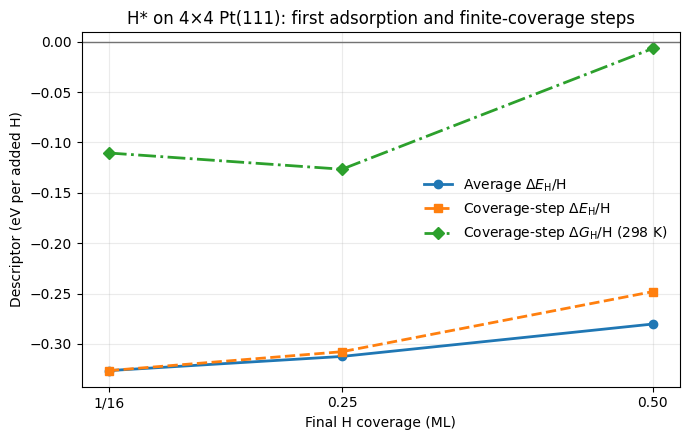

In [17]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(
    energy_table["coverage_ML"],
    energy_table["delta_E_H_average_eV_per_H"],
    "o-",
    lw=2,
    label=r"Average $\Delta E_\mathrm{H}$/H",
)
ax.plot(
    energy_table["coverage_ML"],
    energy_table["delta_E_H_step_eV_per_H"],
    "s--",
    lw=2,
    label=r"Coverage-step $\Delta E_\mathrm{H}$/H",
)
if free_energy_table is not None:
    ax.plot(
        free_energy_table["coverage_ML"],
        free_energy_table["delta_G_H_step_eV_per_H"],
        "D-.",
        lw=2,
        label=rf"Coverage-step $\Delta G_\mathrm{{H}}$/H ({TEMPERATURE_K:.0f} K)",
    )
ax.axhline(0.0, color="0.45", lw=1)
ax.set_xticks([1/16, 0.25, 0.50], ["1/16", "0.25", "0.50"])
ax.set_xlabel("Final H coverage (ML)")
ax.set_ylabel("Descriptor (eV per added H)")
ax.set_title("H* on 4×4 Pt(111): first adsorption and finite-coverage steps")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_ROOT / "coverage_deltaE_deltaG.png", dpi=220)
plt.show()

## 12) Visualize any selected state

In [18]:
import py3Dmol

def view_atoms(atoms, width=520, height=380):
    xyz = f"{len(atoms)}\n\n" + "\n".join(
        f"{symbol} {x:.7f} {y:.7f} {z:.7f}"
        for symbol, (x, y, z) in zip(atoms.get_chemical_symbols(), atoms.positions)
    )
    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, "xyz")
    view.setStyle({"elem": "Pt"}, {"sphere": {"radius": 1.25}, "stick": {"radius": 0.16}})
    view.setStyle({"elem": "H"}, {"sphere": {"radius": 0.40}, "stick": {"radius": 0.10}})
    view.zoomTo()
    return view

STATE_TO_VIEW = 8  # choose 0, 1, 4, or 8
view_atoms(minima[STATE_TO_VIEW]["atoms"]).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 13) Reporting checklist

- **Surface:** four-layer 4×4 Pt(111), 16 surface Pt atoms, 64 Pt atoms total; bottom two layers fixed.
- **PBE condition:** Pt lattice optimized with UMA/`omat` at the PBE level; final PBE VASP inputs use `GGA=PE` and one consistent energy cycle.
- **Screening condition:** UMA/`oc20` is used for adsorbate–surface ranking and is identified as RPBE-trained, not PBE.
- **Single adsorption:** heuristic/high-symmetry, random-site heuristic, and random 1H structures are screened before selecting the first-H minimum.
- **Finite coverage:** 4H (0.25 ML) and 8H (0.50 ML) use separated maximin, random-site heuristic, and random multi-adsorbate streams.
- **Differential definition:** 0→1H is a true single-H differential; 1→4H and 4→8H are per-H block differentials between sampled minima.
- **Thermochemistry:** H*-state harmonic modes plus H₂ ZPE and ideal-gas entropy; the non-periodic H₂ thermochemistry copy fixes the previous Colab error.
- **Audit trail:** generated, prescreened, selected, accepted, rejected, and strategy-minimum tables are all saved.

For publication-quality work, increase sampling/relaxation quotas, test slab thickness and k-point convergence, compute all intermediate $N$ if true nth-H differential energies are required, and replace UMA vibrational corrections with consistent PBE phonons.